# [Video RAG] 프레임 추출

In [1]:
%pip install opencv-python pillow -Uqqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.7 MB/s eta 0:00:00


In [2]:
# 구글 드라이브 마운트 및 연동
from google.colab import drive  # Colab에서 구글드라이브 사용 모듈
drive.mount('/content/drive')   # 현재 런타임에서 내 구글드라이브 마운트(연동)

BASE_PATH = '/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag'

Mounted at /content/drive


In [3]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')

## opencv
**OpenCV**는 "Open Source Computer Vision Library"의 약자로, **실시간 이미지 및 영상 처리**를 위한 오픈소스 라이브러리이다. 인텔에서 개발을 시작했으며, 현재는 다양한 운영체제(Windows, Linux, macOS, Android 등)와 프로그래밍 언어(Python, C++, Java 등)를 지원한다.

**Python에서 OpenCV**는 주로 `cv2` 패키지를 통해 사용하며, 이미지와 영상의 읽기, 쓰기, 변환, 필터링, 객체 인식 등 다양한 컴퓨터 비전 기능을 쉽게 구현할 수 있다.

- **이미지/영상 처리**: 이미지 읽기, 쓰기, 변환, 필터 적용, 색상 변환 등 기본적인 영상 처리 기능을 제공한다.
- **컴퓨터 비전 알고리즘**: 얼굴 인식, 객체 추적, 패턴 분석 등 고급 컴퓨터 비전 기술을 구현할 수 있다.
- **머신러닝 지원**: OpenCV에는 머신러닝 관련 함수도 내장되어 있어, 이미지 분류, 객체 검출 등에 활용할 수 있다.
- **빠른 처리 속도**: 실시간 처리를 위해 최적화되어 있으며, C++ 기반으로 개발되어 빠른 연산이 가능하다.
- **활용 분야**:
  - 얼굴 인식, 객체 추적, 자율주행, 공장 자동화, 의료 영상 분석 등 **다양한 실생활 문제 해결**에 활용된다.

In [9]:
!gdown 1zFdDejlTNGPSL5BVngJWTevOY2jipGrG

Downloading...
From: https://drive.google.com/uc?id=1zFdDejlTNGPSL5BVngJWTevOY2jipGrG
To: /content/image.jpg
100% 98.3k/98.3k [00:00<00:00, 1.39MB/s]


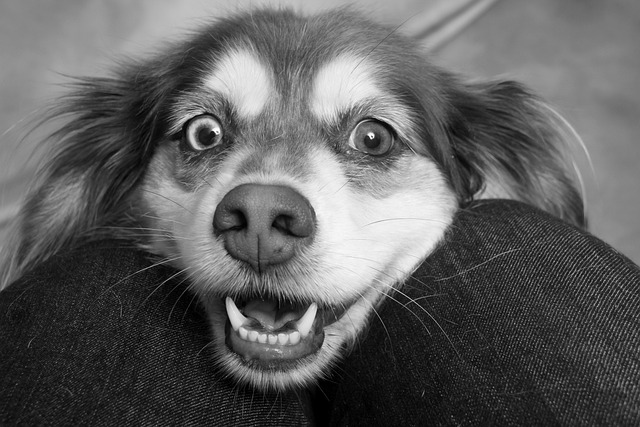

In [10]:
import cv2  # OpenCV : 이미지 입출력/처리
from google.colab.patches import cv2_imshow  # Colab에서 OpenCV 이미지 출력

# colab에서 실행시
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)  # 이미지를 흑백으로 읽기
cv2_imshow(img)  # 이미지 표시

In [11]:
# 로컬실행
# img = cv2.imread('image.jpg')
# cv2.imshow('img', img)
# cv2.waitkey(0) # 키보드입력 무한대기
# cv2.destroyAllWindows()

In [12]:
# Numpy + OpenCV로 단색(빨강/검정/흰/초록/파랑) 생성 및 저장
import numpy as np
import cv2

# 검정색
black = np.zeros((300, 300, 3), dtype=np.uint8)  # (H, W, C) 값을 0으로 채움
cv2.imwrite('black.png', black)

# 흰색
white = np.ones((300, 300, 3) , dtype=np.uint8) * 255  # 1로 채운 값을 255 곱해줌
cv2.imwrite('white.png', white)

# 빨강 : (B, G, R)에서 R만 255
red = np.zeros((300, 300, 3), dtype=np.uint8)
red[:, :, 2] = 255
cv2.imwrite('red.png', red)

# 초록 : (B, G, R)에서 G만 255
green = np.zeros((300, 300, 3), dtype=np.uint8)
green[:, :, 1] = 255
cv2.imwrite('green.png', green)

# 파랑 : (B, G, R)에서 B만 255
blue = np.zeros((300, 300, 3), dtype=np.uint8)
blue[:, :, 0] = 255
cv2.imwrite('blue.png', blue)

True

### 동영상 재생
- cap.read(): colab 재생시 콘솔에 프레임 연속출력
- HTML태그 출력: 동영상 html태그를 통한 출력

In [13]:
# OpenCV로 동영상 프레임을 읽어와서 Colab에서 출력해보기
import cv2

video_path = os.path.join(BASE_PATH, 'videos', 'skiing.mp4')  # 동영상 파일 경로
cap = cv2.VideoCapture(video_path)  # 동영상 캡쳐 생성 (프레임 단위로 읽기)

while cap.isOpened():        # 캡처 객체가 열려있으면
    ret, frame = cap.read()  # 성공여부, 프레임 읽기
    if not ret:
        break
    cv2_imshow(frame)        # Colab에 프레임 출력

cap.release()  # 동영상 캡쳐 리소스 해제

Output hidden; open in https://colab.research.google.com to view.

In [14]:
# HTML(Base64 인코딩)로 Colab 비디오 출력
from IPython.display import HTML  # 노트북에서 HTML 렌더링 모듈
from base64 import b64encode  # 바이너리 데이터 -> Base64 인코딩

video_path = os.path.join(BASE_PATH, 'videos', 'skiing.mp4')  # 동영상 파일 경로
mp4 = open(video_path, 'rb').read()  # mp4 -> 바이너리 (메모리에 로드)
b64_str = b64encode(mp4).decode()    # Base64 인코딩 -> 문자열 디코딩
data_url = f'data:video/mp4;base64,{b64_str}'  # HTML URL 형식으로 구성

HTML(f'''
<video width='200' controls>
    <source src='{data_url}' type='video/mp4'/>
</video>
''')


Output hidden; open in https://colab.research.google.com to view.

## 썸네일 추출

<class 'numpy.ndarray'>
img.size = (1280, 720)
img.width = 1280
img.height = 720
썸네일 변환 후 크기 : img.size = (480, 270)


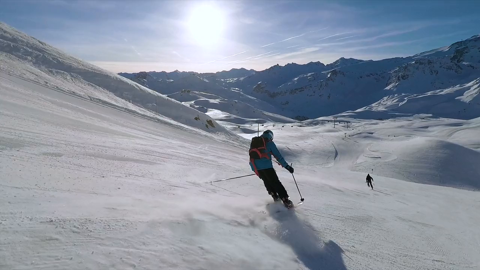

In [15]:
from PIL import Image  # Numpy 배열 -> Image 객체

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()  # 첫 프레임 1장 읽기
cap.release()            # 자원 해제
print(type(frame))       # Numpy ndarray

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # OpenCV(BGR) -> PIL(RGB)
img = Image.fromarray(frame)  # Numpy 배열 -> Image 객체

print(f'{img.size = }')    # PIL(width, height)
print(f'{img.width = }')
print(f'{img.height = }')

img.thumbnail((480, 270))  # 크기 변환
print(f'썸네일 변환 후 크기 : {img.size = }')
img

## 동영상 정보 확인

동영상 파일명 : skiing.mp4
총 프레임 수 : 353.0
프레임 레이트 : 25.00 FPS
동영상 길이 : 14.12 초


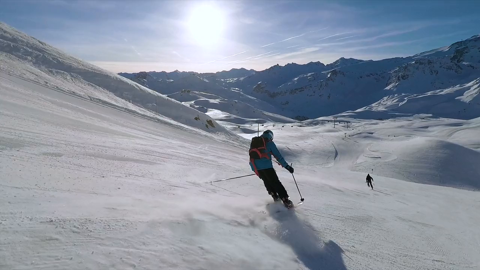



동영상 파일명 : baseball.mp4
총 프레임 수 : 732.0
프레임 레이트 : 50.00 FPS
동영상 길이 : 14.64 초


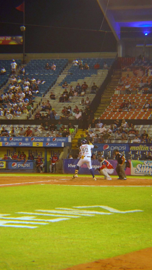



동영상 파일명 : basketball.mp4
총 프레임 수 : 404.0
프레임 레이트 : 25.00 FPS
동영상 길이 : 16.16 초


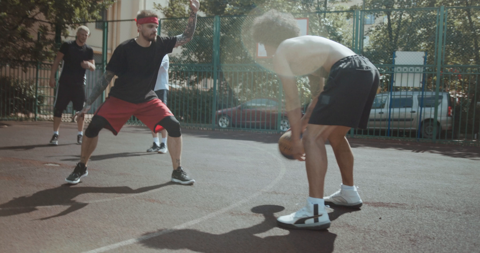



동영상 파일명 : alpinist.mp4
총 프레임 수 : 677.0
프레임 레이트 : 50.00 FPS
동영상 길이 : 13.54 초


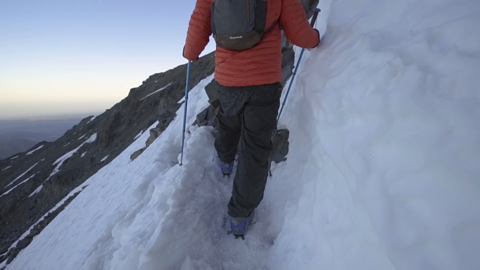



동영상 파일명 : soccer.mp4
총 프레임 수 : 352.0
프레임 레이트 : 25.00 FPS
동영상 길이 : 14.08 초


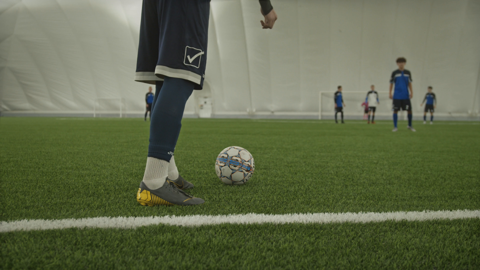

In [17]:
# 동영상 파일명/총프레임/FPS/길이와 첫 프레임 썸네일 출력하는 함수
def show_video_summary(video_dir='videos', video_file=None, thumb_size=(240, 135)):
    assert video_file is not None, "video_file 인수는 반드시 지정해야 합니다."

    video_path = os.path.join(BASE_PATH, video_dir, video_file)
    cap = cv2.VideoCapture(video_path)    # 동영상 캡쳐 객체
    if not cap.isOpened():
        print(f"해당 파일을 열수 없습니다. {video_path}")
        return

    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)  # 총 프레임 수 조회
    fps = cap.get(cv2.CAP_PROP_FPS)                  # 초당 프레임 수(FPS) 조회
    duration = frame_count / fps if fps > 0 else 0   # 동영상 길이(초) 계산

    ret, frame = cap.read()  # 첫 프레임 1장 읽기
    cap.release()            # 자원 해제
    if not ret:
        print(f"썸네일 추출 실패 : {video_path}")
        thumbnail = None
    else:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # BGR -> RGB
        thumbnail = Image.fromarray(frame_rgb)  # ndarray -> Image 객체
        thumbnail.thumbnail(thumb_size)  # 크기 축소

    print(f"동영상 파일명 : {video_file}")
    print(f"총 프레임 수 : {frame_count}")
    print(f"프레임 레이트 : {fps:.2f} FPS")
    print(f"동영상 길이 : {duration:.2f} 초")

    if thumbnail:
        display(thumbnail)

video_dir = 'videos'
for video_file in os.listdir(os.path.join(BASE_PATH, video_dir)):  # 동영상 폴더 내 파일 순회
    if video_file.endswith('.mp4'):  # 확장자가 mp4면
        show_video_summary(video_dir, video_file, thumb_size=(480, 270))
        print(end = "\n\n")

## 프레임 추출

In [19]:
video_dir_path = os.path.join(BASE_PATH, 'videos')  # 동영상 폴더 경로
frame_dir_path = os.path.join(BASE_PATH, 'frames')  # 프레임 이미지 폴더 경로
video_files = [f for f in os.listdir(video_dir_path) if f.endswith('.mp4')]  # mp4파일 리스트

# splitext 예시
video_file_path = os.path.join(video_dir_path, 'abc.mp4')  # 가상 경로
video_file_name = os.path.splitext('abc.mp4')  # (파일명, 확장자)
video_file_name

('abc', '.mp4')

In [24]:
# 동영상에서 일정 간격으로 프레임을 추출해서 이미지로 저장하는 함수
from tqdm.notebook import tqdm  # 노트북용 tqdm

def extract_frames_from_videos(video_dir='videos', frame_dir='frames', frame_interval=1):
    video_dir_path = os.path.join(BASE_PATH, 'videos')  # 동영상 폴더 경로
    frame_dir_path = os.path.join(BASE_PATH, 'frames')  # 프레임 이미지 폴더 경로
    os.makedirs(frame_dir_path, exist_ok=True)  # 프레임 저장 폴더 없으면 생성 (있으면 스킵)
    video_files = [f for f in os.listdir(video_dir_path) if f.endswith('.mp4')]  # mp4파일 리스트

    for idx_file, video_file in enumerate(video_files):
        video_path = os.path.join(video_dir_path, video_file)  # 동영상 경로
        video_name = os.path.splitext(video_file)[0]           # 확장자 제거
        save_subdir = os.path.join(frame_dir_path, video_name)  # 프레임 서브폴더명
        os.makedirs(save_subdir, exist_ok=True)  # 폴더 없으면 생성 (있으면 스킵)

        cap = cv2.VideoCapture(video_path)  # 비디오 캡쳐 객체
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임 수
        idx = 0         # 현재 프레임 인덱스
        saved_cnt = 0   # 저장된 프레임 개수

        pbar = tqdm(total=frame_count, desc=f"{video_name}", leave=True, ncols=100)  # 진행바 설정
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if idx % frame_interval == 0:  # 인터벌 마다
                frame_path = os.path.join(save_subdir, f"{video_name}_frame{idx:05d}.jpg")  # 파일명
                cv2.imwrite(frame_path, frame)  # 프레임을 파일명 이름으로 저장 (BGR)
                saved_cnt += 1
            idx += 1
            pbar.update(1)  # 진행률 1 업데이트
        cap.release()  # 동영상 캡쳐 리소스 해제
        pbar.close()   # 진행률 바 닫음

        # 마지막 파일 처리 후
        if idx_file == len(video_files) -1:
            tqdm.write("")  # tqdm 출력 정리
        tqdm.write(f"{video_name}: 총 {frame_count} 프레임 중 {saved_cnt}개 저장")

    print("모든 동영상의 프레임 추출이 완료되었습니다!")

In [25]:
extract_frames_from_videos(frame_interval=30)  # 30프레임마다 1장씩 저장

skiing:   0%|                                                               | 0/353 [00:00<?, ?it/s]

skiing: 총 353 프레임 중 12개 저장


baseball:   0%|                                                             | 0/732 [00:00<?, ?it/s]

baseball: 총 732 프레임 중 25개 저장


basketball:   0%|                                                           | 0/404 [00:00<?, ?it/s]

basketball: 총 404 프레임 중 14개 저장


alpinist:   0%|                                                             | 0/677 [00:00<?, ?it/s]

alpinist: 총 677 프레임 중 23개 저장


soccer:   0%|                                                               | 0/352 [00:00<?, ?it/s]


soccer: 총 352 프레임 중 12개 저장
모든 동영상의 프레임 추출이 완료되었습니다!
